In [ ]:
%%capture
%%bash

apt install -y libboost-all-dev
pip install -U pip
pip install "pybind11[global]"

pip install aijack

In [ ]:
import random
import numpy as np

In [ ]:
np.random.seed(77)
random.seed(77)

### Data Poisoning

Атака: атакующий модифицирует тренировочный пример, добавляя в обучающую выборку "яд" (poisoned sample), чтобы снизить качество модели на тесте.

In [ ]:
import os
import time
import copy

from tqdm import tqdm

import sklearn
from sklearn import datasets
from sklearn import metrics
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

from aijack.attack import Poison_attack_sklearn

In [ ]:
def plot_image(img):
  plt.figure(figsize=(1, 1))
  plt.imshow(img.reshape(28, 28), cmap="gray")
  plt.axis("off")
  plt.show()

In [ ]:
mnist = datasets.fetch_openml("mnist_784", version=1, data_home=".", return_X_y=True)
imagedata, labeldata = mnist[0].values, mnist[1].values

index_3 = [i for i, x in enumerate(labeldata) if x == "3"]
index_7 = [i for i, x in enumerate(labeldata) if x == "7"]
image_data_3_7 = imagedata[index_3 + index_7]
label_data_3_7 = labeldata[index_3 + index_7]

(
    imagedata_training,
    imagedata_validation,
    labeldata_training,
    labeldata_validation,
) = train_test_split(image_data_3_7, label_data_3_7, test_size=0.2, shuffle=True, random_state=77)

imagedata_training = imagedata_training / 255.0
imagedata_validation = imagedata_validation / 255.0

X_train = imagedata_training[:5000]
y_train = labeldata_training[:5000]
X_valid = imagedata_validation[:500]
y_valid = labeldata_validation[:500]

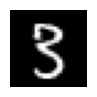

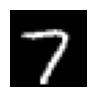

In [ ]:
for num in ['3', '7']:
  img = X_train[np.where(y_train == num)[0][0], :]
  plot_image(img)

In [ ]:
clf = SVC(kernel="linear")
clf.fit(X_train, y_train)

predict = clf.predict(X_valid)

ac_score = metrics.accuracy_score(y_valid, predict)
cl_report = metrics.classification_report(y_valid, predict)
print(cl_report)

              precision    recall  f1-score   support

           3       0.99      0.97      0.98       229
           7       0.98      0.99      0.99       271

    accuracy                           0.98       500
   macro avg       0.98      0.98      0.98       500
weighted avg       0.98      0.98      0.98       500



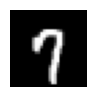

In [ ]:
# initial point
initial_idx = np.where(y_train == "7")[0][42]
xc = copy.deepcopy(X_train[initial_idx, :])
yc = y_train[initial_idx]

train_idx = random.sample(list(range(1, X_train.shape[0])), 100)
X_train_ = copy.copy(X_train[train_idx, :])
y_train_ = copy.copy(y_train[train_idx])
y_train_ = np.where(y_train_ == "7", 1, -1)
y_valid_ = np.where(y_valid == "7", 1, -1)

plot_image(xc)

In [ ]:
attacker = Poison_attack_sklearn(clf, X_train_, y_train_, t=0.5)
xc_attacked, log = attacker.attack(xc, 1, X_valid, y_valid_, num_iterations=200)

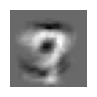

In [ ]:
plot_image(xc_attacked)

In [ ]:
clf = SVC(kernel="linear", C=1)
clf.fit(X_train_, y_train_)
print("before attack: ", clf.score(X_valid, y_valid_))

# add poinsoned data
clf = SVC(kernel="linear", C=1)
clf.fit(
    np.concatenate([X_train_, xc_attacked.reshape(1, -1)]),
    np.concatenate([y_train_, [-1]]),
)
print("after attack: ", clf.score(X_valid, y_valid_))

before attack:  0.956
after attack:  0.846


### Model Inversion

Задача: узнать или восстановить приватные данные по выходу модели (например, создать изображение лица, которое данная модель считает определённой персоной).

[Facial Similarity with Siamese Networks in Pytorch](https://github.com/harveyslash/Facial-Similarity-with-Siamese-Networks-in-Pytorch)

In [ ]:
%%capture
%%bash

git clone https://github.com/harveyslash/Facial-Similarity-with-Siamese-Networks-in-Pytorch.git
mkdir data
mv Facial-Similarity-with-Siamese-Networks-in-Pytorch/data/faces/testing/* data/
mv Facial-Similarity-with-Siamese-Networks-in-Pytorch/data/faces/training/* data/

In [ ]:
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import TensorDataset
from matplotlib import pyplot as plt
import glob
from sklearn.metrics import accuracy_score

from aijack.attack import MI_FACE
from aijack.defense import GeneralMomentAccountant, DPSGDManager
from aijack.utils import NumpyDataset

BASE = "data/"

In [ ]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.fla = nn.Flatten()
        self.fc = nn.Linear(112 * 92, 40)

    def forward(self, x):
        x = self.fla(x)
        x = self.fc(x)
        x = F.softmax(x, dim=1)
        return x

In [ ]:
imgs = []
labels = []
for i in range(1, 41):
    for j in range(1, 11):
        img = cv2.imread(BASE + f"s{i}/{j}.pgm", 0)
        imgs.append(img)
        labels.append(i - 1)

X = np.stack(imgs)
y = np.array(labels)

transform = transforms.Compose(
    [transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]
)
trainset = NumpyDataset(X, y, transform=transform)
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=4, shuffle=True, num_workers=2
)

net = Net()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.005, momentum=0.9)

array([[48, 49, 45, ..., 56, 56, 54],
       [45, 52, 39, ..., 52, 50, 51],
       [45, 50, 42, ..., 48, 53, 50],
       ...,
       [50, 48, 50, ..., 45, 46, 46],
       [45, 54, 49, ..., 46, 47, 47],
       [51, 51, 51, ..., 47, 46, 46]], dtype=uint8)
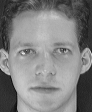

array([[ 60,  60,  62, ...,  40,  53,  46],
       [ 58,  73,  54, ...,  34,  50,  51],
       [ 68,  77,  80, ...,  36,  50,  49],
       ...,
       [ 24, 143, 160, ...,  34,  33,  33],
       [ 18, 136, 161, ...,  36,  36,  31],
       [  9, 111, 168, ...,  32,  34,  34]], dtype=uint8)
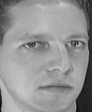

(None, None)

In [ ]:
display(imgs[0]), display(imgs[1])

In [ ]:
for epoch in range(10):
    running_loss = 0
    data_size = 0
    for i, data in enumerate(trainloader, 0):
        inputs, labels = data
        optimizer.zero_grad()

        outputs = net(inputs)
        loss = criterion(outputs, labels.to(torch.int64))
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        data_size += inputs.shape[0]

    print(f"epoch {epoch}: loss is {running_loss/data_size}")


in_preds = []
in_label = []

with torch.no_grad():
    for data in trainloader:
        inputs, labels = data
        outputs = net(inputs)
        in_preds.append(outputs)
        in_label.append(labels)
    in_preds = torch.cat(in_preds)
    in_label = torch.cat(in_label)
print(
    "Test Accuracy is: ",
    accuracy_score(np.array(torch.argmax(in_preds, axis=1)), np.array(in_label)),
)

epoch 0: loss is 0.9152019417285919
epoch 1: loss is 0.8609364205598831
epoch 2: loss is 0.8160346275568009
epoch 3: loss is 0.7824368423223496
epoch 4: loss is 0.7702081650495529
epoch 5: loss is 0.7541229528188705
epoch 6: loss is 0.7427381998300553
epoch 7: loss is 0.7344367510080337
epoch 8: loss is 0.7298152804374695
epoch 9: loss is 0.7238472014665603
Test Accuracy is:  0.85


[Model Inversion Attacks that Exploit Confidence Information and Basic Countermeasures](https://dl.acm.org/doi/pdf/10.1145/2810103.2813677)


> Inspecting facial recognition APIs, it turns out that it is common to give
floating-point confidence measures along with the class label
(person’s name). This enables us to craft attacks that cast
the inversion task as an optimization problem: find the input
that maximizes the returned confidence, subject to the classification also matching the target. We give an algorithm for
solving this problem that uses gradient descent along with
modifications specific to this domain.



In [ ]:
input_shape = (1, 1, 112, 92)
target_label = 11
lam = 0.03
num_itr = 100

mi = MI_FACE(
    net,
    input_shape,
    target_label=target_label,
    num_itr=num_itr,
    lam=lam,
    log_interval=0,
)
x_result_1, log = mi.attack()

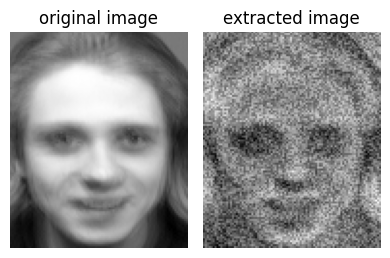

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(4, 3))
axes[0].imshow(
    np.mean([cv2.imread(p, 0) for p in glob.glob(BASE + "s12/*.pgm")], axis=0),
    cmap="gray",
)
axes[0].axis("off")
axes[0].set_title("original image")
axes[1].imshow(x_result_1[0][0].detach().numpy(), cmap="gray")
axes[1].axis("off")
axes[1].set_title("extracted image")
fig.tight_layout()
fig.show()

### Evasion Attack == Input Manipulation

Атака, при которой пример из тестовой выборки модифицируется минимальным образом, чтобы модель ошиблась (adversarial example).

[Evasion Attacks against Machine Learning at Test Time](https://link.springer.com/chapter/10.1007/978-3-642-40994-3_25)

In [ ]:
import os
import time
import copy

import sklearn
from sklearn import datasets
from sklearn import metrics
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

from aijack.attack import Evasion_attack_sklearn

In [ ]:
mnist = datasets.fetch_openml("mnist_784", version=1, data_home=".", return_X_y=True)
imagedata, labeldata = mnist[0].values, mnist[1].values

index_3 = [i for i, x in enumerate(labeldata) if x == "3"]
index_7 = [i for i, x in enumerate(labeldata) if x == "7"]
image_data_3_7 = imagedata[index_3 + index_7]
label_data_3_7 = labeldata[index_3 + index_7]

(
    imagedata_training,
    imagedata_validation,
    labeldata_training,
    labeldata_validation,
) = train_test_split(image_data_3_7, label_data_3_7, test_size=0.2, shuffle=True, random_state=77)

imagedata_training = imagedata_training / 255.0
imagedata_validation = imagedata_validation / 255.0

X_train = imagedata_training[:5000]
y_train = labeldata_training[:5000]
X_valid = imagedata_validation[:500]
y_valid = labeldata_validation[:500]

In [ ]:
clf = SVC(kernel="linear")
clf.fit(X_train, y_train)

predict = clf.predict(X_valid)

ac_score = metrics.accuracy_score(y_valid, predict)
cl_report = metrics.classification_report(y_valid, predict)
print(cl_report)

              precision    recall  f1-score   support

           3       0.99      0.97      0.98       229
           7       0.98      0.99      0.99       271

    accuracy                           0.98       500
   macro avg       0.98      0.98      0.98       500
weighted avg       0.98      0.98      0.98       500



In [ ]:
X_minus_1 = X_train[np.where(y_train == "3")]
attacker = Evasion_attack_sklearn(
    target_model=clf,
    X_minus_1=X_minus_1,
    dmax=(5000 / 255) * 2.5,
    max_iter=300,
    gamma=1 / (X_train.shape[1] * np.var(X_train)),
    lam=10,
    t=0.5,
    h=10,
)

x0 = X_valid[np.where(y_valid == "7")[0][0]]
xm, g_list = attacker.attack(copy.copy(x0))

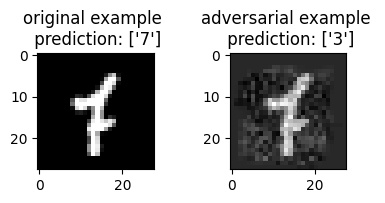

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(4, 2))


axes[0].imshow(x0.reshape(28, 28), cmap="gray")
axes[0].set_title(f"original example \n prediction: {clf.predict(x0.reshape(1, -1))}")

axes[1].imshow(xm.reshape(28, 28), cmap="gray")
axes[1].set_title(
    f"adversarial example \n prediction: {clf.predict(xm.reshape(1, -1))}"
)

fig.tight_layout()
# fig.savefig("output_10.png")
fig.show()

### Membership Inference

Построение "теневых моделей" (shadow models), которые имитируют поведение целевой модели.

Цель: по выходу модели определить, был ли пример в обучающей выборке.

[Membership Inference Attacks Against Machine Learning Models](https://ieeexplore.ieee.org/abstract/document/7958568)

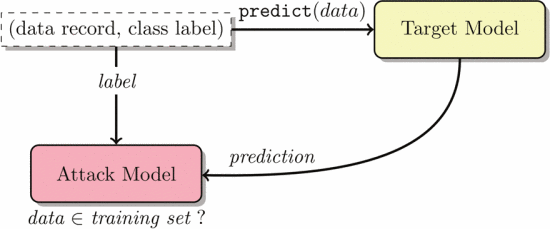

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score

from aijack.attack.membership import ShadowMembershipInferenceAttack
from aijack.utils.utils import TorchClassifier, NumpyDataset

In [ ]:
np.random.seed(42)
torch.manual_seed(42)

df = pd.read_csv("/content/sample_data/mnist_train_small.csv", header=None)

X = df[range(1, 785)].values.astype("float64") / 255
y = df[0].values

# We use the train dataset to train the victim model. The attacker utilize shadow dataset to
# prepare membership inference attack. The test dataset is used to evaluate the result of attack.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=1 / 3, random_state=42
)
X_train, X_shadow, y_train, y_shadow = train_test_split(
    X_train, y_train, test_size=1 / 2, random_state=42
)
# We simulate the situation where the distribution of training dataset is different from the test/shadow datasets.
X_test = 0.5 * X_test + 0.5 * np.random.normal(size=(X_test.shape))

In [ ]:
clf = SVC(probability=True)
clf.fit(X_train, y_train)
clf.score(X_train, y_train), clf.score(X_test, y_test)

(0.9848484848484849, 0.11054447277636119)

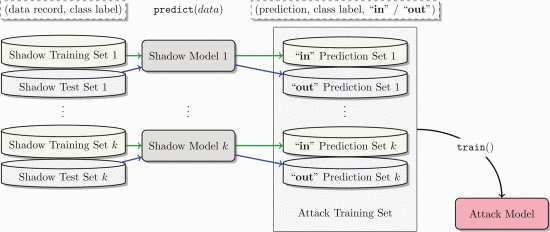

In [ ]:
shadow_models = [SVC(probability=True) for _ in range(2)]
attack_models = [SVC(probability=True) for _ in range(10)]

attacker = ShadowMembershipInferenceAttack(clf, shadow_models, attack_models)
attacker.fit(X_shadow, y_shadow)

In [ ]:
in_result = attacker.predict(clf.predict_proba(X_train), y_train)
out_result = attacker.predict(clf.predict_proba(X_test), y_test)

in_label = np.ones(in_result.shape[0])
out_label = np.zeros(out_result.shape[0])

accuracy_score(
    np.concatenate([in_label, out_label]), np.concatenate([in_result, out_result])
)

0.9738243456086402